In [9]:
import h5py
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner
import jax

from jesterTOV.inference.population.populations import RecycledBinary

# load EOS
m_val, r_val, l_val = np.loadtxt("../../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
n_val, p_val = np.loadtxt("../../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])


latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }


In [34]:
def load_population_posterior(file):

    posterior = {}

    with h5py.File(file) as f:

        for key in ["mu_1", "mu_2", "alpha", "sigma_1", "sigma_2", "m_max", "m_min", "k_coll"]:
            if key in f["posterior"]["parameters"].keys():
                posterior[key] = f["posterior"]["parameters"][key][:]
    
    return pd.DataFrame(posterior)

def load_eos_posterior(file):
    
    posterior = {}

    with h5py.File(file) as f:
        posterior["masses_EOS"] = f["posterior"]["derived_eos"]["masses_EOS"][:]
        posterior["radii_EOS"] = f["posterior"]["derived_eos"]["radii_EOS"][:]
        posterior["lambdas_EOS"] = f["posterior"]["derived_eos"]["Lambdas_EOS"][:]
        posterior["log_prob"] = f["posterior"]["log_prob"][:]

    return posterior

#posterior_gw = load_population_posterior("./gw/outdir_gw/results.h5")
#posterior_gw_1000 = load_population_posterior("./gw_masseval_1000/outdir_gw/results.h5")
#posterior_mm = load_population_posterior("./mm/outdir_mm/results.h5")
#posterior_mm_1000 = load_population_posterior("./mm_masseval_1000/outdir_mm/results.h5")
#
#eos_posterior_gw = load_eos_posterior("./gw/outdir_gw/results.h5")
#eos_posterior_gw_1000 = load_eos_posterior("./gw_masseval_1000/outdir_gw/results.h5")
#eos_posterior_mm = load_eos_posterior("./mm_masseval_1000/outdir_mm/results.h5")

def corner_plot(posterior, parameter_names, fig, color="purple"):

    truths = dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3)

    labels = [latex_labels.get(p,p) for p in parameter_names]

    corner.corner(posterior[parameter_names], 
                  smooth=True, 
                  levels=[0.68, 0.95],
                  fig=fig, 
                  plot_density=False,
                  fill_contours=True,
                  plot_datapoints=False,
                  truths=truths,
                  color=color,
                  truth_color="red",
                  labels=labels,
                  hist_kwargs=dict(density=True))

def plot_eos(eos_posterior, ax, quantity="radii_EOS", color="purple"):

    m_arr = np.linspace(1, 2.5, 120)

    best_ind = eos_posterior["log_prob"].argmax()

    quantity_interp = np.vstack([
                                np.interp(m_arr, eos_posterior["masses_EOS"][j,:], eos_posterior[quantity][j,:], left=np.nan) 
                                     for j in range(eos_posterior["masses_EOS"].shape[0]) 
    ])
    
    quantiles = np.vstack([
                           corner.quantile(quantity_interp[:, j], q=[0.025, 0.16, 0.5, 0.84, 0.975])
                           for j in range(m_arr.shape[0])
    ])
    
    #ax.plot(quantiles[:, 2], m_arr, color=color)
    ax.plot(quantiles[:, 1], m_arr, color=color, linestyle="dashed")
    ax.plot(quantiles[:, 3], m_arr, color=color, linestyle="dashed")
    ax.fill_betweenx(m_arr, quantiles[:, 0], quantiles[:, 4], color=color, alpha=0.1)

    if quantity=="lambdas_EOS":
        ax.plot(l_val, m_val, color="red", zorder=3)
        ax.set_ylabel("$M$ [$M_\\odot$]")
        ax.set_xlabel("$\\Lambda$")
        ax.set(ylim=(1, 2), xscale="log", xlim=(20, 2e3))
        ax.plot(eos_posterior["lambdas_EOS"][best_ind], eos_posterior["masses_EOS"][best_ind], color=color, linestyle="solid")
    else:
        ax.plot(r_val, m_val, color="red", zorder=3)
        ax.set_ylabel("$M$ [$M_\\odot$]")
        ax.set_xlabel("$R$ [km]")
        ax.set(ylim=(1, 2.5), xlim=(10, 14))
        ax.plot(eos_posterior["radii_EOS"][best_ind], eos_posterior["masses_EOS"][best_ind], color=color, linestyle="solid")


def plot_both(posterior_file, figs=None, parameter_names=None, color="purple"):
    pop_posterior = load_population_posterior(posterior_file)
    eos_posterior = load_eos_posterior(posterior_file)

    if parameter_names is None:
        parameter_names = list(pop_posterior.keys())


    n_params = len(parameter_names)
    if figs is None:
        fig1, _ = plt.subplots(n_params, n_params, figsize=(10/7*n_params, 10/7*n_params))
        fig2, _ =  plt.subplots(2,1,figsize=(4,8))

        figs = [fig1, fig2]

    corner_plot(pop_posterior, parameter_names=parameter_names, fig=figs[0], color=color)

    ax = figs[1].get_axes()
    plot_eos(eos_posterior, ax[0], color=color)
    plot_eos(eos_posterior, ax[1], quantity="lambdas_EOS", color=color)

    return figs


(array([ 236.,  395., 1360., 2310., 1330.,  499.,  424.,  183.,  143.,
         120.]),
 array([1.20010415, 1.24008046, 1.28005676, 1.32003307, 1.36000937,
        1.39998568, 1.43996198, 1.47993829, 1.51991459, 1.5598909 ,
        1.5998672 ]),
 <BarContainer object of 10 artists>)

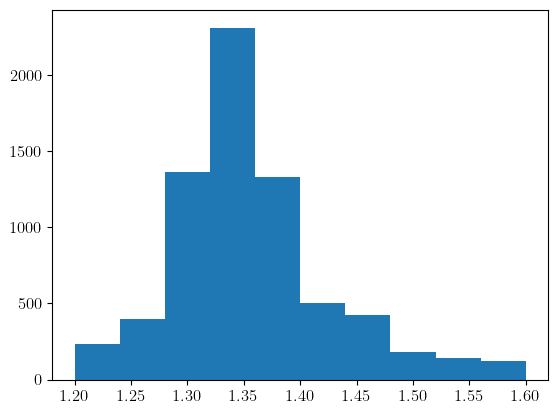

In [32]:
pop_mm = load_population_posterior('./mm/outdir_mm/results.h5')
plt.hist(pop_mm["k_coll"])

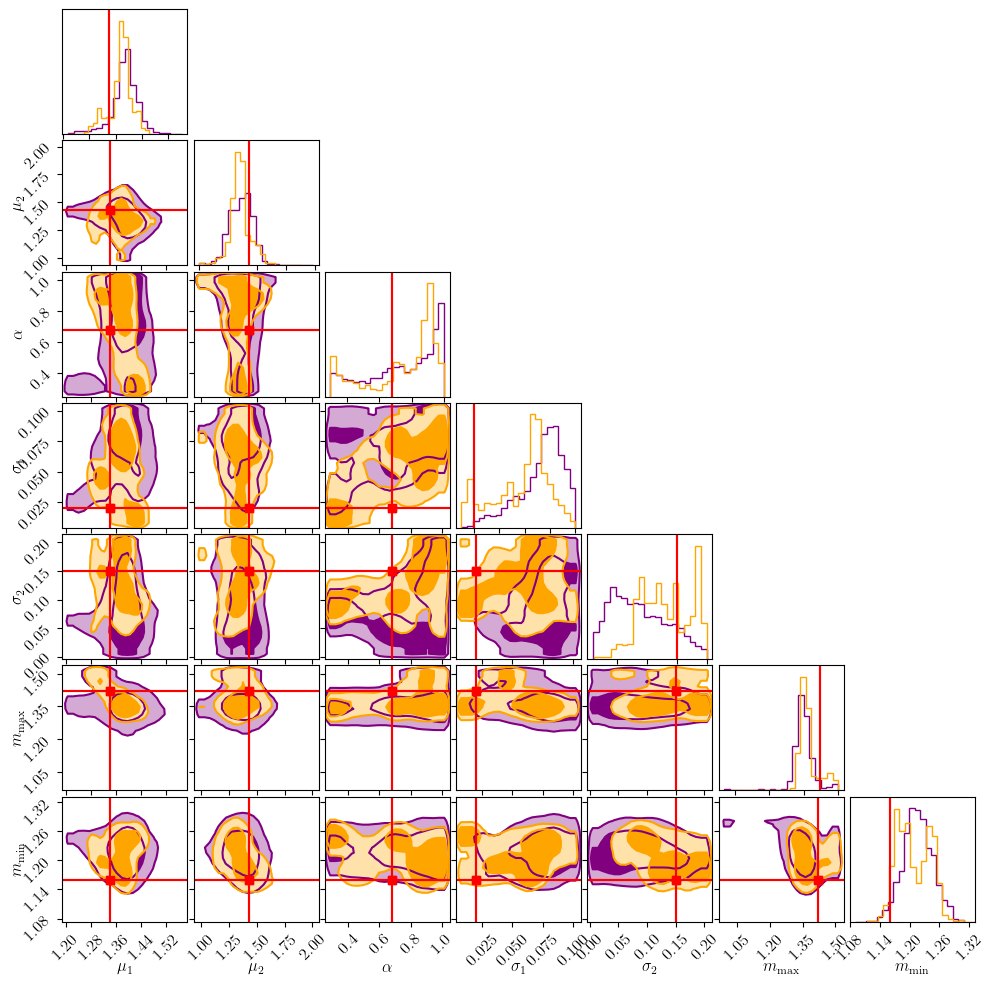

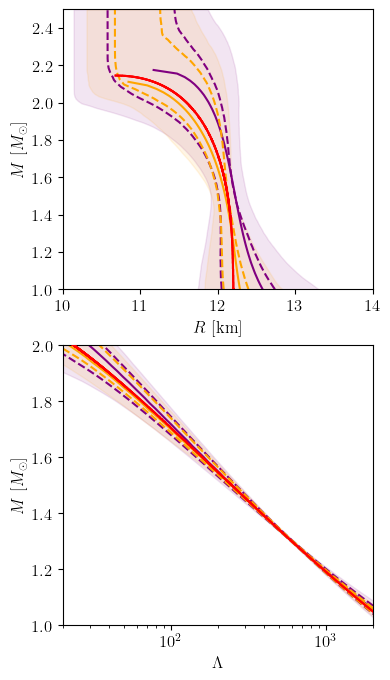

In [35]:
parameter_names = ["mu_1", "mu_2", "alpha", "sigma_1", "sigma_2", "m_max", "m_min"]
figs = plot_both("./gw_masseval_1000/outdir_gw/results.h5", parameter_names=parameter_names);
figs = plot_both("./mm/outdir_mm/results.h5", parameter_names=parameter_names, figs=figs, color="orange")

In [20]:
pop_posterior_mm = load_population_posterior("./mm_10/outdir_mm/results.h5")

events = pd.read_csv("../events.dat", sep=" ")

m1, m2 = RecycledBinary(jax.random.key(850), pop_posterior_mm.loc[0].to_dict(), size=10_000)

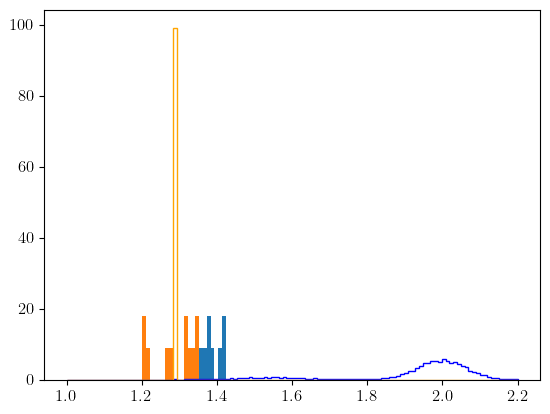

In [25]:
bins = np.linspace(1, 2.2, 120)
plt.hist(m1, histtype="step", color="blue", bins=bins, density=True)
plt.hist(m2, histtype="step", color="orange", bins=bins, density=True)
plt.hist(events.loc[:10, "mass_1_source"], bins=bins, density=True)
plt.hist(events.loc[:10, "mass_2_source"], bins=bins, density=True)
plt.show()

In [23]:
events.loc[:10, "mass_1_source"]

0     1.347770
1     1.418059
2     1.419791
3     1.369415
4     1.408725
5     1.384053
6     1.338482
7     1.378517
8     1.313910
9     1.379869
10    1.354168
Name: mass_1_source, dtype: float64